In [1]:
import pandas as pd

# =====================================================================
# TASK 1: Load dataset into Jupyter and display basic information
# =====================================================================
# Reading the training dataset file we placed in our project folder
df = pd.read_csv('train.csv')

print("--- TASK 1: BASIC INFORMATION ---")
# Displays structural layout, data types, and memory consumption
df.info()

print("\n" + "="*60 + "\n")

# =====================================================================
# TASK 2: Identify number of rows, columns, data types, and missing values
# =====================================================================
print("--- TASK 2: STRUCTURAL ANALYSIS ---")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

print("\nData Types per Column:")
print(df.dtypes)

print("\nMissing Values per Column:")
# isnull() marks missing data as True, .sum() counts them up
print(df.isnull().sum())

print("\n" + "="*60 + "\n")

# =====================================================================
# TASK 3: Exploratory inspection (First, last, and random records)
# =====================================================================
print("--- TASK 3: DATA INSPECTION ---")
print("\nFirst 5 Records (Head):")
print(df.head(5))

print("\nLast 5 Records (Tail):")
print(df.tail(5))

print("\n3 Randomly Selected Records (Sample):")
print(df.sample(3))

--- TASK 1: BASIC INFORMATION ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


--- TASK 2: STRUCTURAL ANALYSIS ---
Total Rows: 891
Total Columns: 12

Data Types per Column:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object

In [2]:
# --- TASK 4: Handling Missing Values ---
print("--- TASK 4: HANDLING MISSING VALUES ---")

# 1. Drop the 'Cabin' column because too much data is missing
# axis=1 means drop a column (axis=0 would mean drop a row)
df.drop(columns=['Cabin'], inplace=True)
print("Dropped 'Cabin' column.")

# 2. Impute missing 'Age' values with the Median age
median_age = df['Age'].median()
df['Age'].fillna(median_age, inplace=True)
print(f"Filled missing Age values with Median: {median_age}")

# 3. Impute missing 'Embarked' values with the Mode (most common port)
# [0] is used because .mode() returns a Series, and we want the first value
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'].fillna(mode_embarked, inplace=True)
print(f"Filled missing Embarked values with Mode: '{mode_embarked}'")

# Double-check: Are there any missing values left?
print("\nMissing values remaining:")
print(df.isnull().sum())

--- TASK 4: HANDLING MISSING VALUES ---
Dropped 'Cabin' column.
Filled missing Age values with Median: 28.0
Filled missing Embarked values with Mode: 'S'

Missing values remaining:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


C:\Users\Dell\AppData\Local\Temp\ipykernel_29104\1416943465.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(median_age, inplace=True)
C:\Users\Dell\AppData\Local\Temp\ipykernel_29104\1416943465.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

In [3]:
# --- TASK 5: Identify and Remove Duplicates ---
print("--- TASK 5: DUPLICATE CHECK ---")

# Count how many rows are completely identical
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate records found: {duplicate_count}")

# Remove duplicates if any exist
if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates successfully removed!")
else:
    print("No duplicates to remove. Your data is unique!")

--- TASK 5: DUPLICATE CHECK ---
Number of duplicate records found: 0
No duplicates to remove. Your data is unique!


--- TASK 6 & 7: OUTLIER ANALYSIS ON 'FARE' ---
IQR: 23.09 | Lower Limit: -26.72 | Upper Limit: 65.63


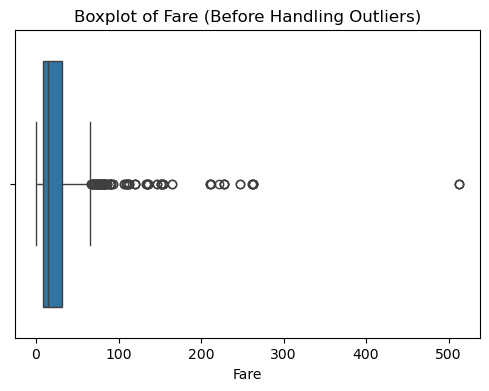

Outliers handled by capping values to IQR thresholds.


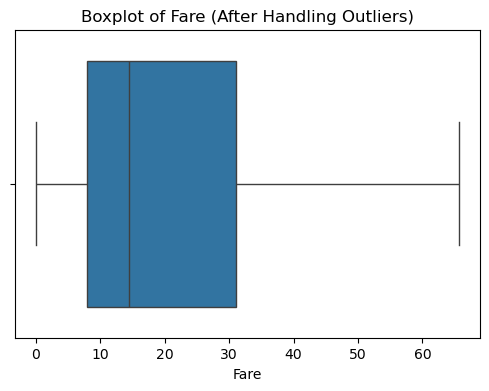

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- TASK 6: Detect Outliers in 'Fare' using IQR ---
print("--- TASK 6 & 7: OUTLIER ANALYSIS ON 'FARE' ---")

# Step 1: Calculate IQR limits
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print(f"IQR: {IQR:.2f} | Lower Limit: {lower_limit:.2f} | Upper Limit: {upper_limit:.2f}")

# Step 2: Visualize outliers with a boxplot BEFORE capping
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Fare'])
plt.title("Boxplot of Fare (Before Handling Outliers)")
plt.show()

# --- TASK 7: Handle Outliers using Capping (Winsorization) ---
# We cap values outside the lower and upper limits
df['Fare'] = np.clip(df['Fare'], lower_limit, upper_limit)

print("Outliers handled by capping values to IQR thresholds.")

# Visualize AFTER capping
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Fare'])
plt.title("Boxplot of Fare (After Handling Outliers)")
plt.show()

In [6]:
from sklearn.preprocessing import LabelEncoder

# --- TASK 8: Categorical Encoding ---
print("--- TASK 8: CATEGORICAL ENCODING ---")

# 1. Label Encoding on 'Sex' (Since there are only two categories)
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
print("Label Encoded 'Sex' column (Male/Female -> 0/1).")

# 2. One-Hot Encoding on 'Embarked' (Since there are 3 ports)
# pd.get_dummies automatically splits the column into Embarked_C, Embarked_Q, Embarked_S
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True, dtype=int)
print("One-Hot Encoded 'Embarked' column and dropped first to avoid redundancy.")

print("\nEncoding Complete! Preview of encoded columns:")
print(df[['Sex', 'Embarked_Q', 'Embarked_S']].head())

--- TASK 8: CATEGORICAL ENCODING ---
Label Encoded 'Sex' column (Male/Female -> 0/1).
One-Hot Encoded 'Embarked' column and dropped first to avoid redundancy.

Encoding Complete! Preview of encoded columns:
   Sex  Embarked_Q  Embarked_S
0    1           0           1
1    0           0           0
2    0           0           1
3    0           0           1
4    1           0           1


In [7]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# --- TASK 9 & 10: Feature Scaling ---
print("--- TASKS 9 & 10: FEATURE SCALING ---")

# 1. Min-Max Normalization on 'Age' (Scales to range [0, 1])
min_max_scaler = MinMaxScaler()
# We use double brackets [['Age']] because Scikit-learn expects a 2D array input
df['Age_scaled'] = min_max_scaler.fit_transform(df[['Age']])

# 2. Standardization on 'Fare' (Mean = 0, Std Dev = 1)
std_scaler = StandardScaler()
df['Fare_scaled'] = std_scaler.fit_transform(df[['Fare']])

print("Feature scaling complete!")
print(df[['Age', 'Age_scaled', 'Fare', 'Fare_scaled']].head())

--- TASKS 9 & 10: FEATURE SCALING ---
Feature scaling complete!
    Age  Age_scaled     Fare  Fare_scaled
0  22.0    0.271174   7.2500    -0.820552
1  38.0    0.472229  65.6344     2.031623
2  26.0    0.321438   7.9250    -0.787578
3  35.0    0.434531  53.1000     1.419297
4  35.0    0.434531   8.0500    -0.781471


--- TASK 11: CORRELATION ANALYSIS ---


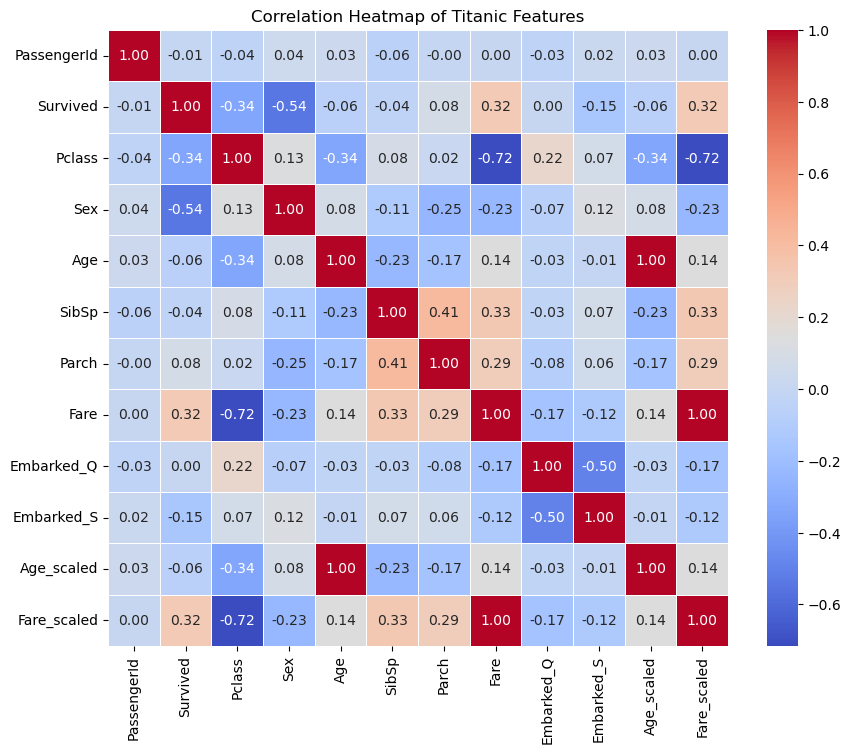

Correlation of features with Survival status:
Survived       1.000000
Fare           0.317430
Fare_scaled    0.317430
Parch          0.081629
Embarked_Q     0.003650
PassengerId   -0.005007
SibSp         -0.035322
Age_scaled    -0.064910
Age           -0.064910
Embarked_S    -0.149683
Pclass        -0.338481
Sex           -0.543351
Name: Survived, dtype: float64


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

print("--- TASK 11: CORRELATION ANALYSIS ---")

# We only calculate correlation on numerical columns because math functions 
# cannot calculate correlation on text columns like Name or Ticket.
numerical_cols = df.select_dtypes(include=['int64', 'float64', 'int32']).columns
corr_matrix = df[numerical_cols].corr()

# Generate the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Titanic Features")
plt.show()

# Interpret the highest correlations with our target 'Survived'
print("Correlation of features with Survival status:")
print(corr_matrix['Survived'].sort_values(ascending=False))

In [ ]:
print("--- TASK 12: FEATURE ENGINEERING ---")

# 1. Combine SibSp and Parch + 1 (the passenger themselves) to get FamilySize
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# 2. Create a binary column 'IsAlone' (1 if family size is 1, else 0)
df['IsAlone'] = 1
df.loc[df['FamilySize'] > 1, 'IsAlone'] = 0

print("New features created successfully!")
print(df[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head(5))

In [9]:
print("--- TASKS 13 & 14: DATA CLEANING & TYPE CONVERSION ---")

# Task 13: Convert data types where necessary
# Convert 'Survived' and 'IsAlone' to integer/float categories if they aren't already
df['Survived'] = df['Survived'].astype('int')

# Task 14: Handle inconsistent/noisy data
# Let's clean the Name text just in case there are accidental trailing or leading spaces
df['Name'] = df['Name'].str.strip()

print("Data types converted and text columns stripped of empty leading/trailing spaces.")

--- TASKS 13 & 14: DATA CLEANING & TYPE CONVERSION ---
Data types converted and text columns stripped of empty leading/trailing spaces.


In [10]:
from sklearn.model_selection import train_test_split

print("--- TASK 15: TRAIN-TEST SPLIT ---")

# 1. Define Features (X) and Target (y)
# We drop non-numeric structural columns like Name and Ticket before feeding to ML algorithms
X = df.drop(columns=['Survived', 'Name', 'Ticket', 'PassengerId'])
y = df['Survived']

# 2. Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")
print(f"Training Target Shape: {y_train.shape}")

--- TASK 15: TRAIN-TEST SPLIT ---
Training Features Shape: (712, 10)
Testing Features Shape: (179, 10)
Training Target Shape: (712,)


In [12]:
# To use SMOTE, you may need to install the imbalanced-learn library first:
# Run: !pip install imbalanced-learn in a Jupyter cell if not already installed.

from imblearn.over_sampling import SMOTE

print("--- TASK 16: DATA BALANCING (SMOTE) ---")
print(f"Original training class distribution:\n{y_train.value_counts()}")

# Initialize and apply SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"\nBalanced training class distribution:\n{y_train_balanced.value_counts()}")

--- TASK 16: DATA BALANCING (SMOTE) ---
Original training class distribution:
Survived
0    444
1    268
Name: count, dtype: int64

Balanced training class distribution:
Survived
0    444
1    444
Name: count, dtype: int64


--- TASK 17: VISUAL DISTRIBUTION COMPARISON ---


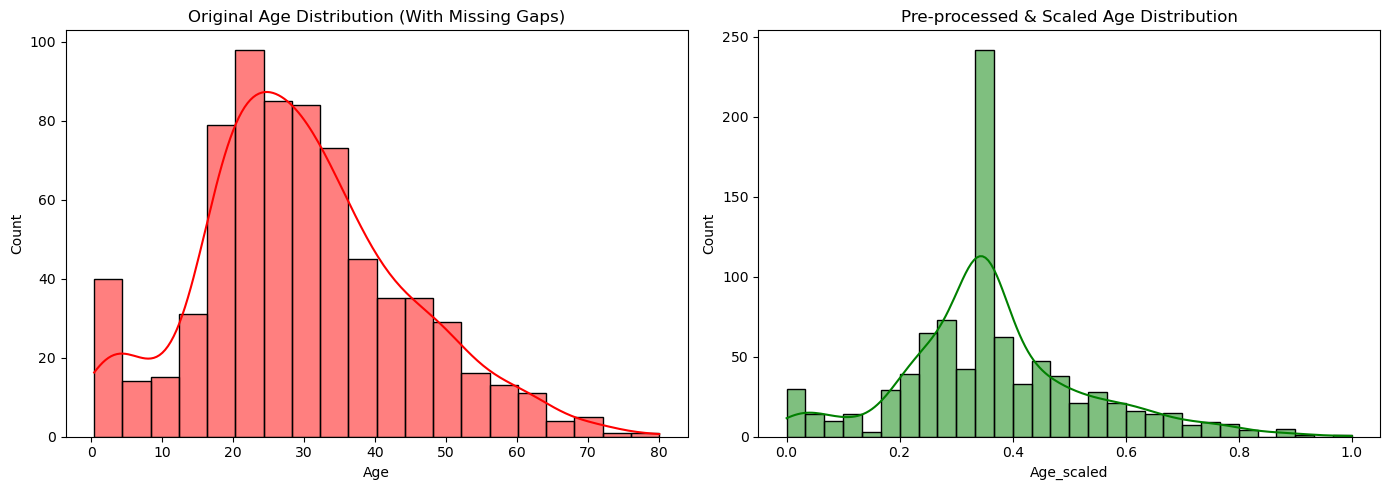

In [13]:
print("--- TASK 17: VISUAL DISTRIBUTION COMPARISON ---")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot original Age distribution (we can load original again to show)
original_df = pd.read_csv('train.csv')
sns.histplot(original_df['Age'].dropna(), ax=axes[0], kde=True, color='red')
axes[0].set_title("Original Age Distribution (With Missing Gaps)")

# Plot pre-processed Age distribution
sns.histplot(df['Age_scaled'], ax=axes[1], kde=True, color='green')
axes[1].set_title("Pre-processed & Scaled Age Distribution")

plt.tight_layout()
plt.show()

In [14]:
# --- TASK 18: Summary of changes ---
print("--- TASK 18: PRE-PROCESSING COMPARISON SUMMARY ---")
print(f"Original dataset shape: {original_df.shape}")
print(f"Cleaned dataset shape: {df.shape}")
print(f"Features ready for ML training: {list(X_train.columns)}")

# --- TASK 19: Save the cleaned dataset ---
# index=False prevents pandas from writing a useless 'Unnamed: 0' row numbers column
df.to_csv('cleaned_titanic_dataset.csv', index=False)
print("\n--- TASK 19: Cleaned dataset saved as 'cleaned_titanic_dataset.csv'!")

--- TASK 18: PRE-PROCESSING COMPARISON SUMMARY ---
Original dataset shape: (891, 12)
Cleaned dataset shape: (891, 14)
Features ready for ML training: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S', 'Age_scaled', 'Fare_scaled']

--- TASK 19: Cleaned dataset saved as 'cleaned_titanic_dataset.csv'!
